In [339]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedShuffleSplit

In [340]:
titanic=pd.read_csv("Titanic-Dataset.csv", usecols=['Survived', 'Pclass','Sex', 'Age','SibSp','Parch', 'Fare','Embarked'])

In [341]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [342]:
titanic['Family']=titanic['Parch']+titanic['SibSp']

In [343]:
titanic.drop(['Parch', 'SibSp'], axis=1,inplace=True)

<Axes: xlabel='Survived', ylabel='count'>

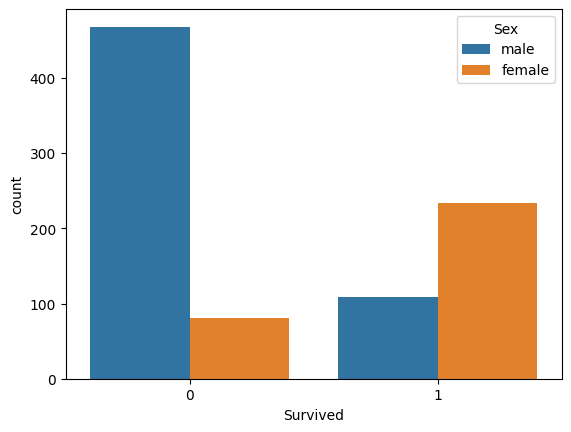

In [344]:
import seaborn as sns
sns.countplot(titanic, x='Survived',hue='Sex')


<Axes: xlabel='Survived', ylabel='count'>

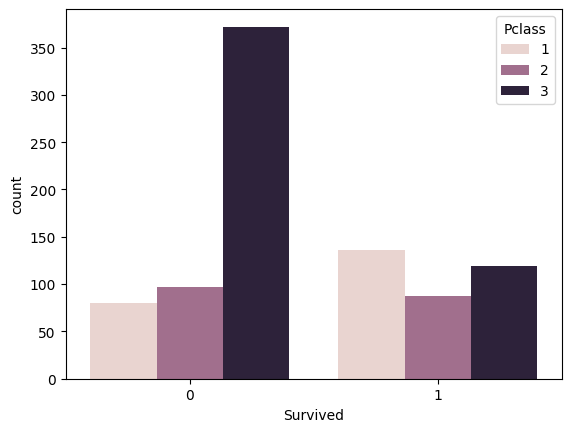

In [345]:
sns.countplot(titanic, x='Survived',hue='Pclass')

<Axes: xlabel='Survived', ylabel='count'>

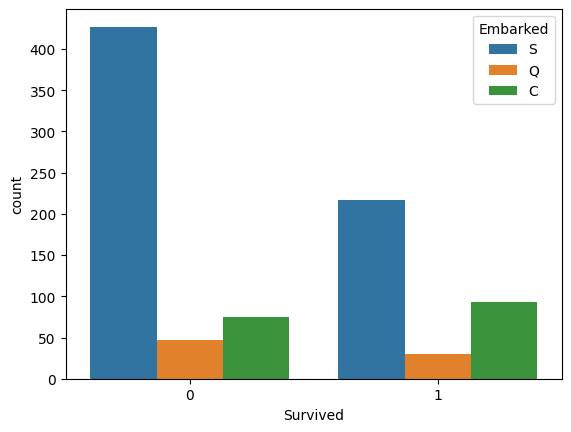

In [346]:
sns.countplot(titanic, x='Survived',hue='Embarked')

<Axes: xlabel='Family', ylabel='count'>

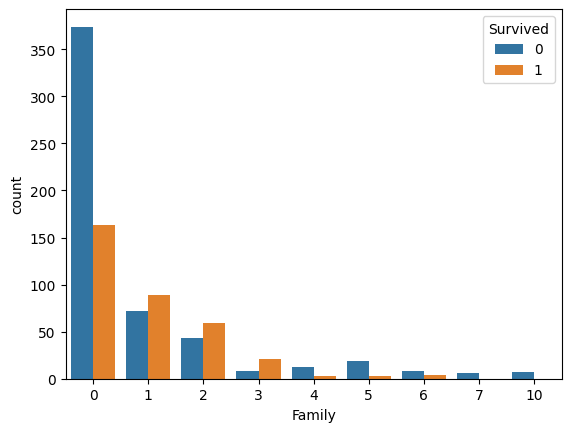

In [347]:
sns.countplot(titanic, x='Family',hue='Survived')

<Axes: xlabel='Age', ylabel='Density'>

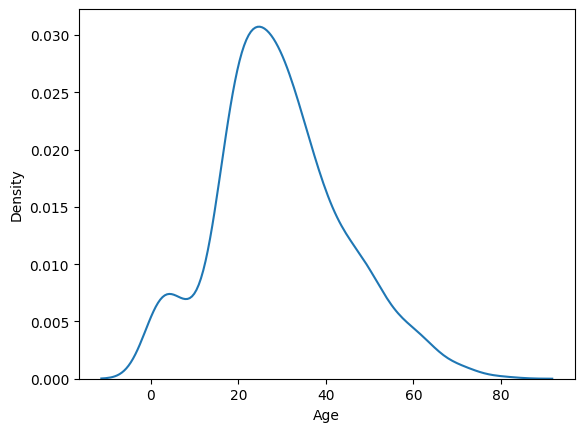

In [348]:
sns.kdeplot(titanic, x='Age')

<Axes: xlabel='Fare', ylabel='Density'>

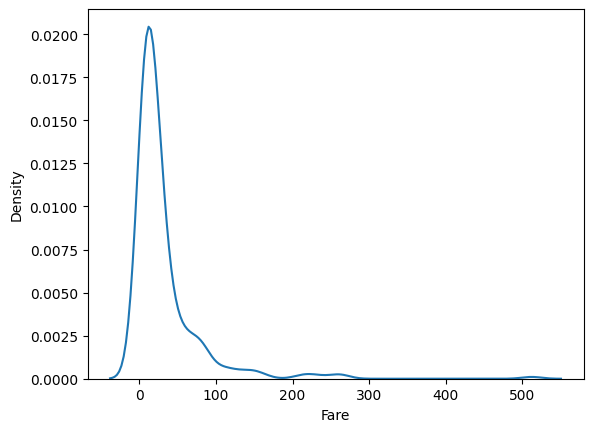

In [349]:
sns.kdeplot(titanic, x='Fare')

<Axes: xlabel='Age'>

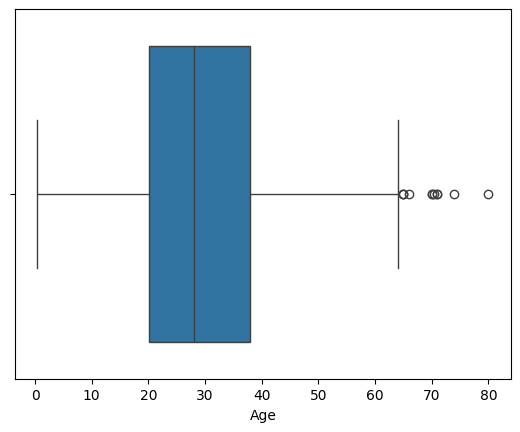

In [350]:
sns.boxplot(titanic, x='Age')


<Axes: xlabel='Fare'>

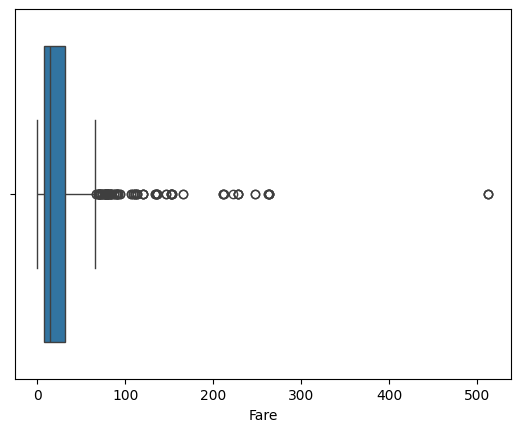

In [351]:
sns.boxplot(titanic, x='Fare')

In [352]:
titanic.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
Family        0
dtype: int64

In [353]:
titanic.duplicated().sum()

np.int64(112)

In [354]:
titanic.drop_duplicates(inplace=True, ignore_index=True)

In [355]:
titanic.duplicated().sum()

np.int64(0)

In [356]:
titanic.sample(5)

,Survived,Pclass,Sex,Age,Fare,Embarked,Family
564,0,3,female,41.0,39.6875,S,5
337,1,3,female,NaN,7.2292,C,0
212,1,2,male,19.0,10.5000,S,0
686,1,1,female,17.0,57.0000,S,1
615,0,3,male,42.0,7.6500,S,0


In [357]:
titanic['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
774    39.0
775    19.0
776     NaN
777    26.0
778    32.0
Name: Age, Length: 779, dtype: float64

In [358]:
titanic['Age']=titanic['Age'].fillna(titanic['Age'].median())

In [359]:
titanic['Age_category']=np.ceil(titanic['Age']/16)
titanic['Age_category']=titanic['Age_category'].clip(upper=5)

<Axes: >

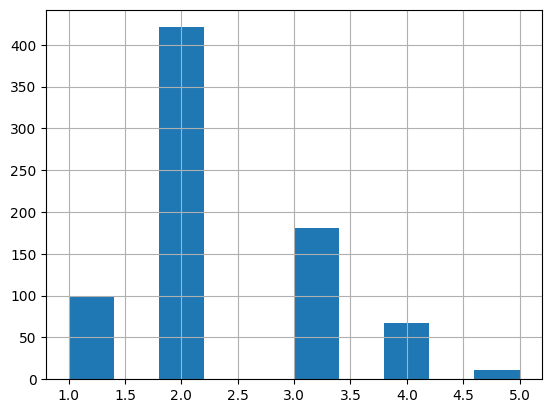

In [360]:
titanic['Age_category'].hist()

In [361]:
stratified=StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in stratified.split(titanic, titanic['Age_category']):
    train=titanic.loc[train_index]
    test=titanic.loc[test_index]

In [362]:
print(train.shape)
test.shape

(623, 8)


(156, 8)

In [363]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score 
from sklearn.compose import ColumnTransformer

In [364]:
train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Family,Age_category
34,0,1,male,28.0,82.1708,C,1,2.0
16,0,3,male,2.0,29.1250,Q,5,1.0
650,1,1,male,28.0,30.0000,S,0,2.0
631,1,1,female,38.0,227.5250,C,0,3.0
494,1,3,male,22.0,7.2250,C,0,2.0


In [365]:
train.drop(columns=['Age_category'],inplace=True)
test.drop(columns=['Age_category'],inplace=True)

In [366]:
train_features=train.drop(columns='Survived')
train_features

,Pclass,Sex,Age,Fare,Embarked,Family
34,1,male,28.0,82.1708,C,1
16,3,male,2.0,29.1250,Q,5
650,1,male,28.0,30.0000,S,0
631,1,female,38.0,227.5250,C,0
494,3,male,22.0,7.2250,C,0
...,...,...,...,...,...,...
233,1,male,37.0,52.5542,S,2
741,3,male,42.0,7.5500,S,0
470,1,male,28.0,221.7792,S,0
630,3,male,19.0,7.6500,S,0


In [367]:
test_features=test.drop(columns='Survived')
test_features

,Pclass,Sex,Age,Fare,Embarked,Family
731,2,male,0.83,18.7500,S,2
597,1,male,36.00,512.3292,C,1
531,1,male,49.00,56.9292,C,1
294,3,female,26.00,7.8542,S,0
288,2,male,30.00,24.0000,C,1
...,...,...,...,...,...,...
697,3,male,25.00,7.8958,S,0
281,1,female,50.00,247.5208,C,1
646,3,male,11.00,18.7875,C,0
106,3,male,22.00,8.0500,S,0


In [368]:
train_label=train['Survived']
train_label

34     0
16     0
650    1
631    1
494    1
      ..
233    1
741    0
470    0
630    0
260    0
Name: Survived, Length: 623, dtype: int64

In [369]:
test_label=test['Survived']
test_label

731    1
597    1
531    1
294    1
288    0
      ..
697    0
281    1
646    0
106    0
468    0
Name: Survived, Length: 156, dtype: int64

In [370]:
train_features.head()

,Pclass,Sex,Age,Fare,Embarked,Family
34,1,male,28.0,82.1708,C,1
16,3,male,2.0,29.1250,Q,5
650,1,male,28.0,30.0000,S,0
631,1,female,38.0,227.5250,C,0
494,3,male,22.0,7.2250,C,0


In [371]:
pipe1=Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
]
)

In [372]:
pipe2=Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
]
)

In [430]:
pipe3=Pipeline([
    ('encoder', OneHotEncoder(drop = 'first', sparse_output=False, handle_unknown='ignore')),
]
)

In [431]:
full_pipeline=ColumnTransformer([
    ('ct1', pipe1,[2]),
    ('ct2', pipe2,[0,3]),
    ('ct3', pipe3,[1,4])
],remainder='passthrough')

In [432]:
full_pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ct1', ...), ('ct2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

In [433]:
train_features

,Pclass,Sex,Age,Fare,Embarked,Family
34,1,male,28.0,82.1708,C,1
16,3,male,2.0,29.1250,Q,5
650,1,male,28.0,30.0000,S,0
631,1,female,38.0,227.5250,C,0
494,3,male,22.0,7.2250,C,0
...,...,...,...,...,...,...
233,1,male,37.0,52.5542,S,2
741,3,male,42.0,7.5500,S,0
470,1,male,28.0,221.7792,S,0
630,3,male,19.0,7.6500,S,0


In [434]:
train_transformed=full_pipeline.fit_transform(train_features)

In [435]:
pd.DataFrame(train_transformed)

,0,1,2,3,4,5,6,7
0,-0.115763,-1.426504,0.991756,1.0,0.0,0.0,0.0,1.0
1,-2.010133,0.887850,-0.112120,1.0,1.0,0.0,0.0,5.0
2,-0.115763,-1.426504,-0.093911,1.0,0.0,1.0,0.0,0.0
3,0.612841,-1.426504,4.016558,0.0,0.0,0.0,0.0,0.0
4,-0.552925,0.887850,-0.567856,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
618,0.539981,-1.426504,0.375439,1.0,0.0,1.0,0.0,2.0
619,0.904283,0.887850,-0.561093,1.0,0.0,1.0,0.0,0.0
620,-0.115763,-1.426504,3.896988,1.0,0.0,1.0,0.0,0.0
621,-0.771506,0.887850,-0.559012,1.0,0.0,1.0,0.0,0.0


In [436]:
test_transformed=full_pipeline.transform(test_features)

In [438]:
test_transformed

array([[-2.09537993, -0.26932697, -0.32802236, ...,  1.        ,
         0.        ,  2.        ],
       [ 0.46712058, -1.42650425,  9.94329558, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.41430587, -1.42650425,  0.46648175, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-1.35438959,  0.8878503 , -0.32724199, ...,  0.        ,
         0.        ,  0.        ],
       [-0.55292511,  0.8878503 , -0.55068795, ...,  1.        ,
         0.        ,  0.        ],
       [-0.11576267,  0.8878503 , -0.56776869, ...,  0.        ,
         0.        ,  0.        ]], shape=(156, 8))

In [439]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier()
tree.fit(train_transformed,train_label)
predict_labels=tree.predict(test_transformed)

In [440]:
from sklearn.metrics import accuracy_score
accuracy_score(test_label,predict_labels)

0.7307692307692307

In [445]:
from sklearn.model_selection import cross_val_score
cross_val_score(tree,train_transformed, train_label,cv=10,scoring='accuracy').mean()

np.float64(0.7368919610855095)

In [446]:
from sklearn.ensemble import RandomForestClassifier
forest=RandomForestClassifier()
forest.fit(train_transformed,train_label)
predict_labels_1=forest.predict(test_transformed)

In [447]:
accuracy_score(predict_labels_1, test_label)

0.7884615384615384

In [448]:
cross_val_score(forest,train_transformed, train_label,cv=10,scoring='accuracy').mean()

np.float64(0.7625960061443932)